# **AML LAB**

## **Lab 5 (Experiment 4) - 23/02/2026**

##Customer Churn Prediction: Develop a model to predict customer churn in a subscription-based business.

##Pipeline:-
### 1. Problem Definition
### 2. Data Understanding
### 3. Preprocessing (Encoding)
### 4. Feature-Target Split
### 5. Train-Test Split
### 6. Regression / Classification Model
### 7. Training
### 8. Prediction
### 9. Evaluation (Accuracy, Precision, Recall)
### 10. Graphical Analysis

###1. Import Required Libraries

In [ ]:
# Import Required Libraries

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

###2. Load Dataset

In [ ]:
# Load Customer Churn Dataset

df = pd.read_csv("/content/drive/MyDrive/Applied_ML_Lab/Lab_5/customer_churn_dataset.csv")

# Display first 5 rows
df.head()

,CustomerID,Gender,Age,Tenure_Months,SubscriptionType,MonthlyCharges,TotalCharges,PaymentMethod,SupportTickets,ContractType,Churn
0,CUST1000,Male,49,54,Standard,99.33,4912.77,Net Banking,1,Two Year,0
1,CUST1001,Female,56,8,Standard,12.01,604.59,Debit Card,2,Two Year,0
2,CUST1002,Male,66,27,Basic,57.62,2019.39,Cash,4,Two Year,0
3,CUST1003,Male,69,27,Premium,97.08,4848.88,Credit Card,7,Two Year,0
4,CUST1004,Male,49,34,Standard,54.69,4334.26,Credit Card,9,One Year,1


###3. Data Understanding

In [ ]:
# Dataset Structure and Missing Values

# Display column information
df.info()

# Check missing values
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerID        200 non-null    object 
 1   Gender            200 non-null    object 
 2   Age               200 non-null    int64  
 3   Tenure_Months     200 non-null    int64  
 4   SubscriptionType  200 non-null    object 
 5   MonthlyCharges    200 non-null    float64
 6   TotalCharges      200 non-null    float64
 7   PaymentMethod     200 non-null    object 
 8   SupportTickets    200 non-null    int64  
 9   ContractType      200 non-null    object 
 10  Churn             200 non-null    int64  
dtypes: float64(2), int64(4), object(5)
memory usage: 17.3+ KB


,0
CustomerID,0
Gender,0
Age,0
Tenure_Months,0
SubscriptionType,0
MonthlyCharges,0
TotalCharges,0
PaymentMethod,0
SupportTickets,0
ContractType,0


###4. Handle Missing Values

In [ ]:
# Handle Missing Values

# Drop rows with missing values (if any)
df = df.dropna()

###5. Encode Categorical Variables

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Encode Categorical Variables
le = LabelEncoder()

# Convert all object type columns into numeric
for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col])

df['Churn'] = le.fit_transform(df['Churn'])
df_encoded = pd.get_dummies(df, drop_first=True)


###6. Define Features (X) and Target (y)

In [ ]:
# Feature–Target Split

# Target variable
y = df_encoded['Churn']

# Input features
X = df_encoded.drop('Churn', axis=1)

###7. Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

# Train–Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

###8. Choose the Classification Model

In [ ]:
from sklearn.linear_model import LogisticRegression

# Initialize Logistic Regression Model
model = LogisticRegression(max_iter=1000)

###9. Train the Model

In [ ]:
# Train the Model

model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

###10. Make Predictions

In [ ]:
# Predict Customer Churn

y_pred = model.predict(X_test)

###11. Evaluate Model Performance

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Evaluate Model Performance

accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("Accuracy:", accuracy)
print("\nConfusion Matrix:\n", cm)
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.8

Confusion Matrix:
 [[32  1]
 [ 7  0]]

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.97      0.89        33
           1       0.00      0.00      0.00         7

    accuracy                           0.80        40
   macro avg       0.41      0.48      0.44        40
weighted avg       0.68      0.80      0.73        40



### 12. Graphical Evaluation

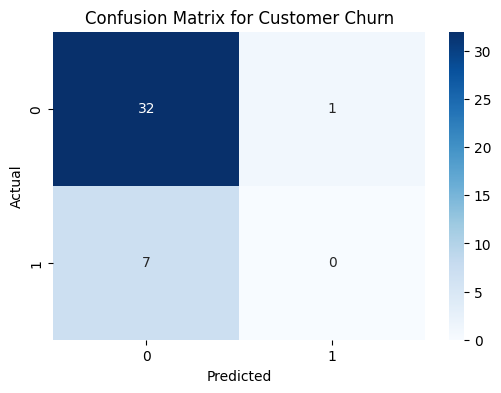

In [ ]:
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix for Customer Churn")
plt.show()